In [2]:

# IMPORT LIBRARIES

import pandas as pd
import numpy as np

import matplotlib
matplotlib.use("Agg")

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

# LOAD DATASET

df = pd.read_csv("/content/Unemployment in India.csv")

# DATA CLEANING

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

print("DATASET INFORMATION")

print("\nShape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst Five Rows")
print(df.head())

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

# Remove rows containing missing values
df.dropna(inplace=True)

# Remove extra spaces in string columns
for col in ["Region", "Frequency", "Area"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

# Convert Date column
df["Date"] = pd.to_datetime(
    df["Date"].str.strip(),
    format="%d-%m-%Y"
)

# Rename columns for easier coding
df.rename(columns={
    "Estimated Unemployment Rate (%)":"Unemployment_Rate",
    "Estimated Employed":"Employed",
    "Estimated Labour Participation Rate (%)":"Labour_Participation_Rate"
}, inplace=True)

# Create additional features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.strftime("%b")
df["YearMonth"] = df["Date"].dt.to_period("M")

# Mark COVID Period
df["Period"] = np.where(
    df["Date"] < "2020-03-25",
    "Pre-COVID",
    "COVID"
)

print("\nCleaned Shape:", df.shape)

print("\nDate Range")
print(df["Date"].min(), "to", df["Date"].max())

print("\nNumber of States")
print(df["Region"].nunique())

# DESCRIPTIVE STATISTICS

print("\nStatistical Summary")

print(df.describe())


# NATIONAL TREND

national_trend = (
    df.groupby("Date")["Unemployment_Rate"]
    .mean()
    .reset_index()
)


# COVID ANALYSIS

pre_covid_avg = (
    df[df["Period"]=="Pre-COVID"]
    ["Unemployment_Rate"]
    .mean()
)

covid_avg = (
    df[df["Period"]=="COVID"]
    ["Unemployment_Rate"]
    .mean()
)

increase = (
    (covid_avg-pre_covid_avg)
    /pre_covid_avg
)*100

peak = national_trend.loc[
    national_trend["Unemployment_Rate"].idxmax()
]

print("\nCOVID IMPACT")
print("="*50)

print("Pre-COVID Average:",
      round(pre_covid_avg,2))

print("COVID Average:",
      round(covid_avg,2))

print("Increase:",
      round(increase,2),"%")

print("Peak Unemployment")

print(peak)


# STATE ANALYSIS

state_pre = (
    df[df["Period"]=="Pre-COVID"]
    .groupby("Region")["Unemployment_Rate"]
    .mean()
)

state_covid = (
    df[df["Period"]=="COVID"]
    .groupby("Region")["Unemployment_Rate"]
    .mean()
)

state_compare = pd.DataFrame({
    "Pre_COVID":state_pre,
    "COVID":state_covid
})

state_compare["Increase"] = (
    state_compare["COVID"]
    - state_compare["Pre_COVID"]
)

state_compare = state_compare.sort_values(
    by="Increase",
    ascending=False
)

print("\nTop States with Highest Increase")

print(state_compare.head(10))

# SEASONAL ANALYSIS

pre_df = df[df["Period"]=="Pre-COVID"]

monthly = (
    pre_df
    .groupby("Month_Name")["Unemployment_Rate"]
    .mean()
)

order = [
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
]

monthly = monthly.reindex(
    [i for i in order if i in monthly.index]
)


# RURAL VS URBAN


area_trend = (
    df.groupby(["Date","Area"])
    ["Unemployment_Rate"]
    .mean()
    .reset_index()
)

area_average = (
    df.groupby(["Period","Area"])
    ["Unemployment_Rate"]
    .mean()
    .reset_index()
)


# CORRELATION


correlation = df[
    [
        "Unemployment_Rate",
        "Employed",
        "Labour_Participation_Rate"
    ]
].corr()

print("\nCorrelation Matrix")

print(correlation)

DATASET INFORMATION

Shape: (768, 7)

Columns:
Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

First Five Rows
           Region         Date Frequency  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019   Monthly                             3.65   
1  Andhra Pradesh   30-06-2019   Monthly                             3.05   
2  Andhra Pradesh   31-07-2019   Monthly                             3.75   
3  Andhra Pradesh   31-08-2019   Monthly                             3.32   
4  Andhra Pradesh   30-09-2019   Monthly                             5.17   

   Estimated Employed  Estimated Labour Participation Rate (%)   Area  
0          11999139.0                                    43.24  Rural  
1          11755881.0                                    42.05  Rural  
2          12086707.0                                    43.50  Rural  
3 

[None, None, None, None, None, None, None]

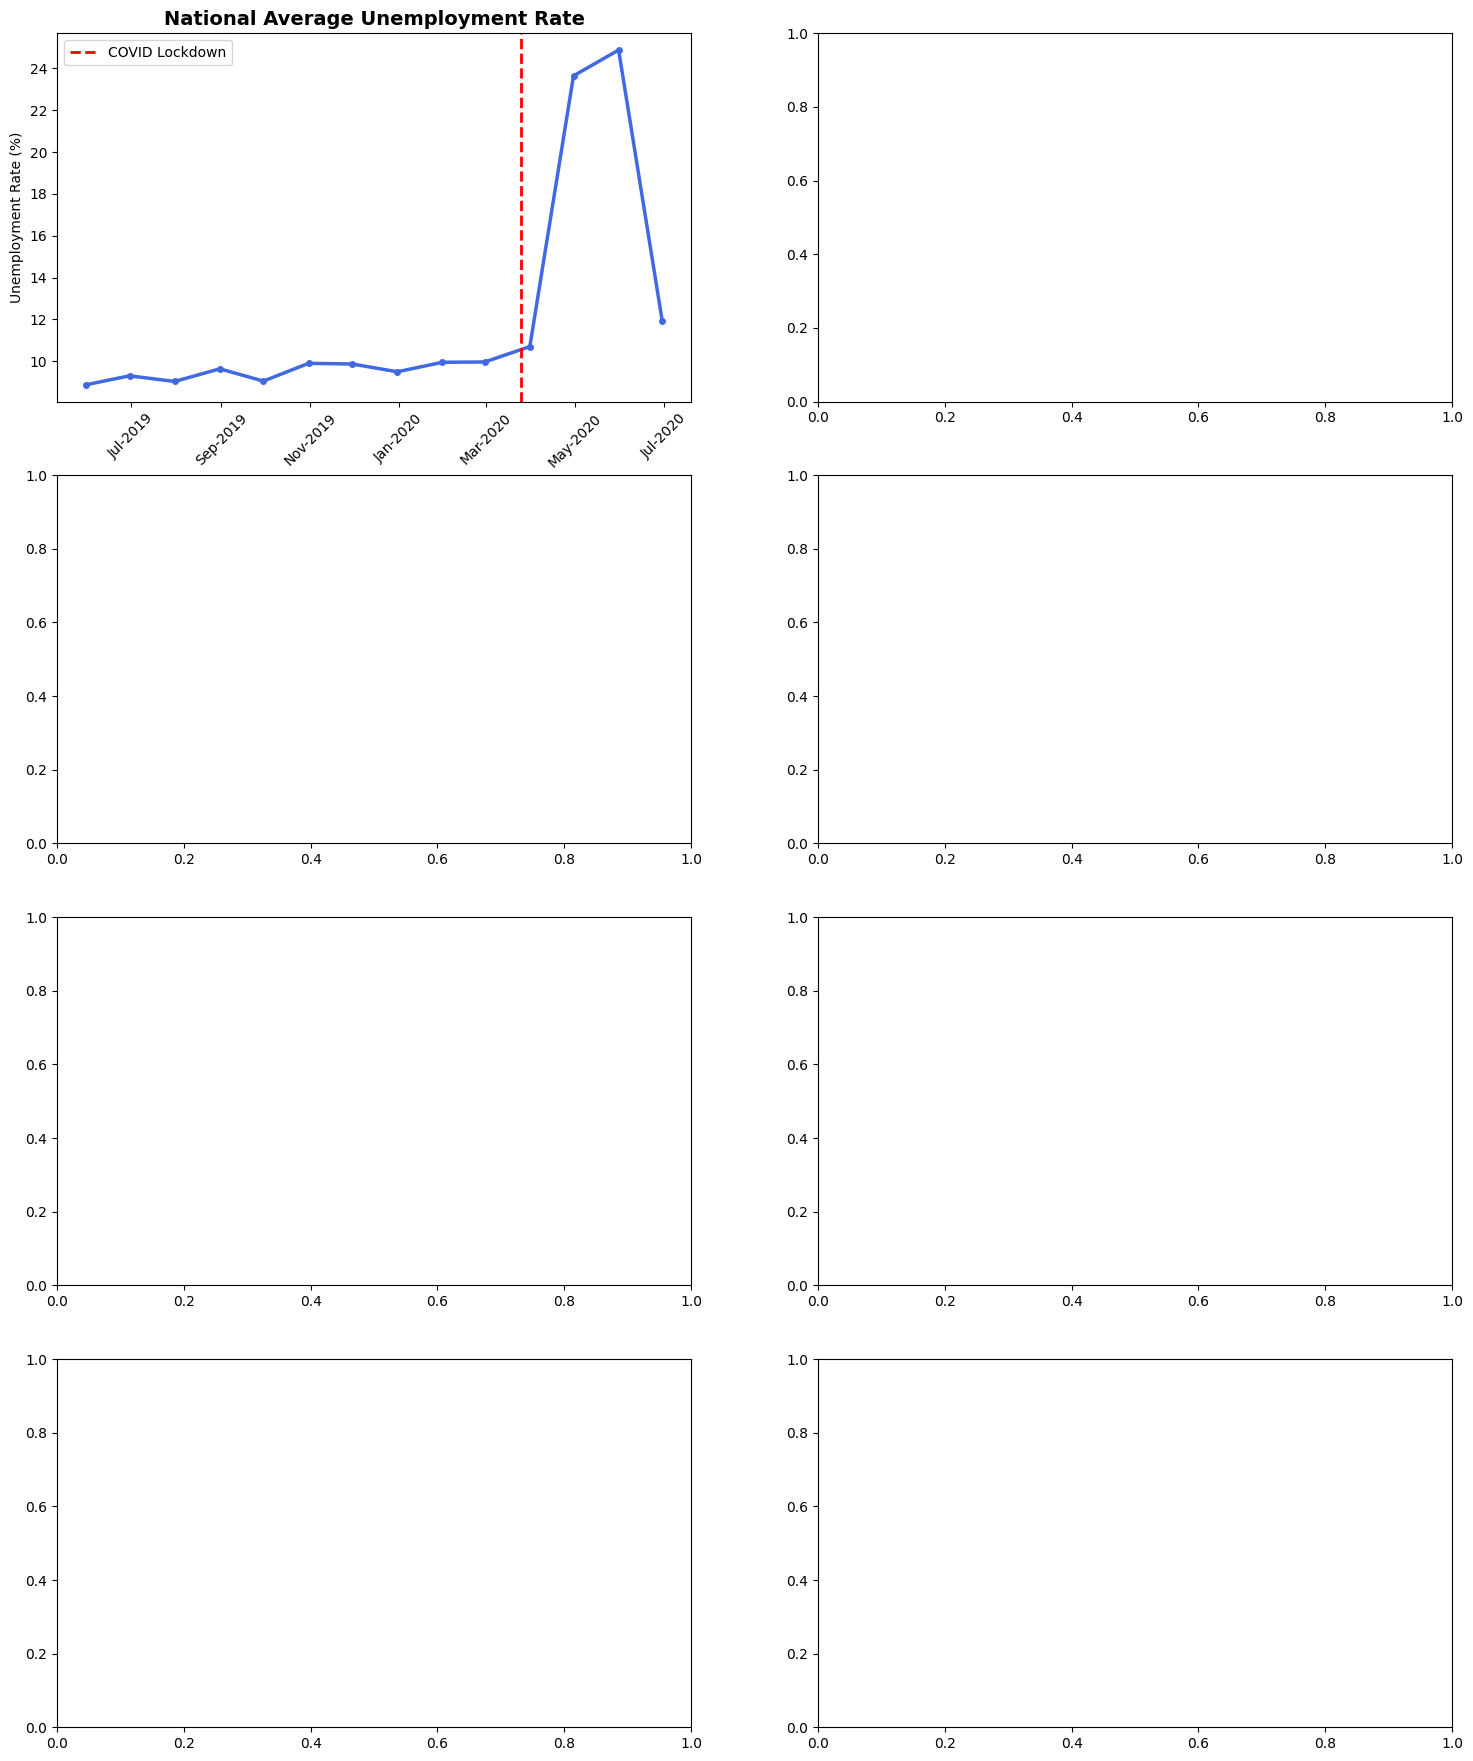

In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# fig, axes are defined here to make the plotting code runnable for this cell
fig, axes = plt.subplots(4, 2, figsize=(18, 22))

# 1. National Unemployment Trend

ax = axes[0,0]

ax.plot(
    national_trend["Date"],
    national_trend["Unemployment_Rate"],
    color="royalblue",
    linewidth=2.5,
    marker="o",
    markersize=4
)

ax.axvline(
    pd.Timestamp("2020-03-25"),
    color="red",
    linestyle="--",
    linewidth=2,
    label="COVID Lockdown"
)

ax.set_title(
    "National Average Unemployment Rate",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Date")
ax.set_ylabel("Unemployment Rate (%)")

ax.legend()

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b-%Y")
)

plt.setp(ax.get_xticklabels(), rotation=45)

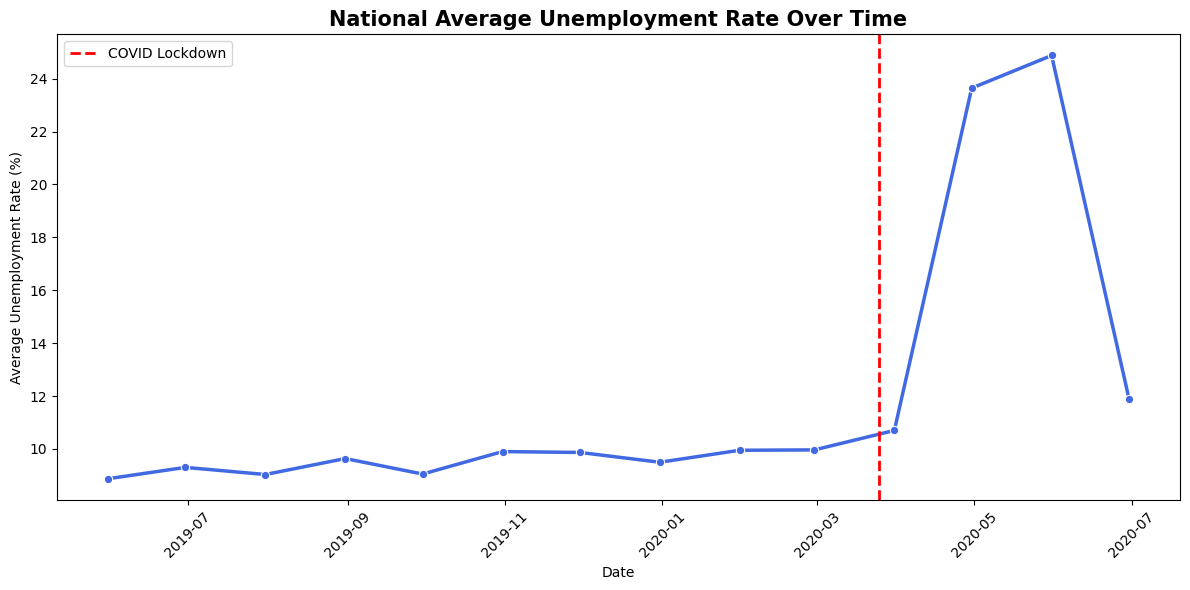

In [18]:
# Graph 1: National Unemployment Trend


plt.figure(figsize=(12,6))

sns.lineplot(
    data=national_trend,
    x="Date",
    y="Unemployment_Rate",
    marker="o",
    linewidth=2.5,
    color="royalblue"
)

plt.axvline(
    pd.Timestamp("2020-03-25"),
    color="red",
    linestyle="--",
    linewidth=2,
    label="COVID Lockdown"
)

plt.title(
    "National Average Unemployment Rate Over Time",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()

plt.show()

In [21]:
import numpy as np

# Create Pre-COVID and COVID labels
df["Period"] = np.where(
    df["Date"] < "2020-03-25",
    "Pre-COVID",
    "COVID"
)

# Calculate average unemployment
pre_covid_avg = df[df["Period"] == "Pre-COVID"]["Unemployment_Rate"].mean()

covid_avg = df[df["Period"] == "COVID"]["Unemployment_Rate"].mean()

print(pre_covid_avg)
print(covid_avg)

9.509533582089553
17.774362745098042


/tmp/ipykernel_1086/2602990346.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


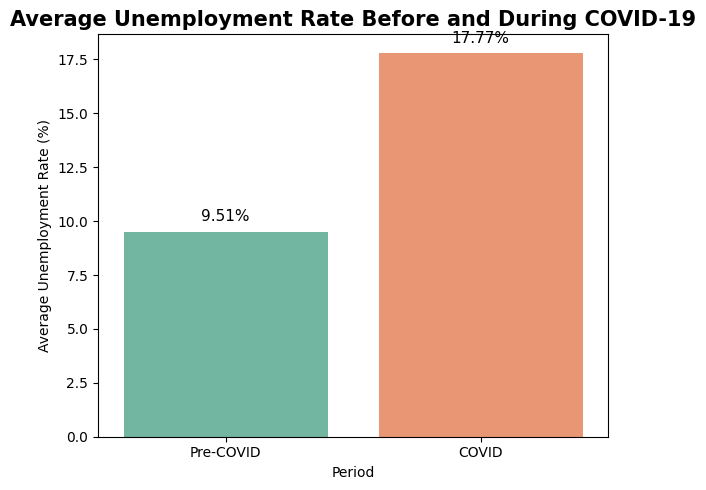

In [22]:
# Graph 2: Pre-COVID vs COVID Comparison


comparison = pd.DataFrame({
    "Period": ["Pre-COVID", "COVID"],
    "Rate": [pre_covid_avg, covid_avg]
})

plt.figure(figsize=(6,5))

sns.barplot(
    data=comparison,
    x="Period",
    y="Rate",
    palette="Set2"
)

plt.title(
    "Average Unemployment Rate Before and During COVID-19",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")

for index, value in enumerate(comparison["Rate"]):
    plt.text(
        index,
        value + 0.5,
        f"{value:.2f}%",
        ha="center",
        fontsize=11
    )

plt.tight_layout()

plt.show()

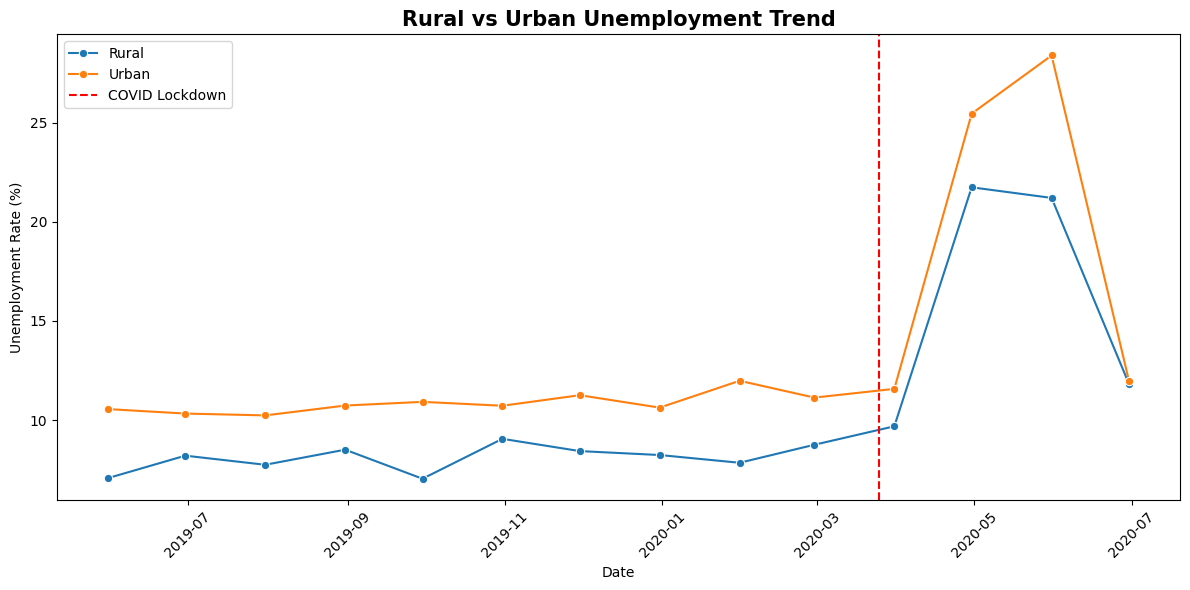

In [23]:
# Graph 3: Rural vs Urban Unemployment Trend


area_trend = (
    df.groupby(["Date", "Area"])["Unemployment_Rate"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=area_trend,
    x="Date",
    y="Unemployment_Rate",
    hue="Area",
    marker="o"
)

plt.axvline(
    pd.Timestamp("2020-03-25"),
    color="red",
    linestyle="--",
    label="COVID Lockdown"
)

plt.title("Rural vs Urban Unemployment Trend", fontsize=15, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_1086/1211574735.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


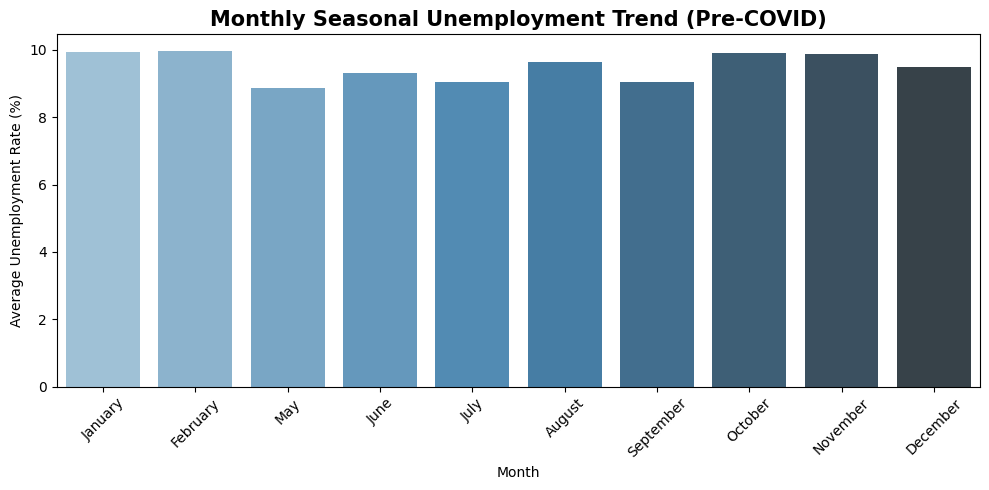

In [24]:
# Graph 4: Monthly Seasonal Trend


pre_df = df[df["Date"] < "2020-03-25"]

monthly = (
    pre_df.groupby(pre_df["Date"].dt.month_name())["Unemployment_Rate"]
          .mean()
)

order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly = monthly.reindex([m for m in order if m in monthly.index])

plt.figure(figsize=(10,5))

sns.barplot(
    x=monthly.index,
    y=monthly.values,
    palette="Blues_d"
)

plt.title("Monthly Seasonal Unemployment Trend (Pre-COVID)", fontsize=15, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1086/1178615270.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


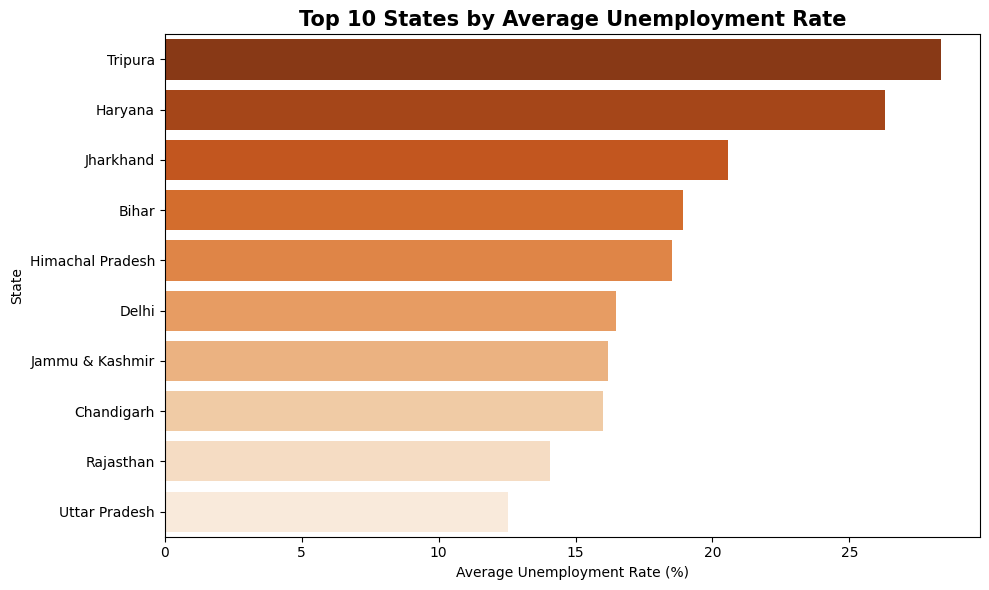

In [25]:
# Graph 5: Top 10 States


top_states = (
    df.groupby("Region")["Unemployment_Rate"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_states.values,
    y=top_states.index,
    palette="Oranges_r"
)

plt.title("Top 10 States by Average Unemployment Rate", fontsize=15, fontweight="bold")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

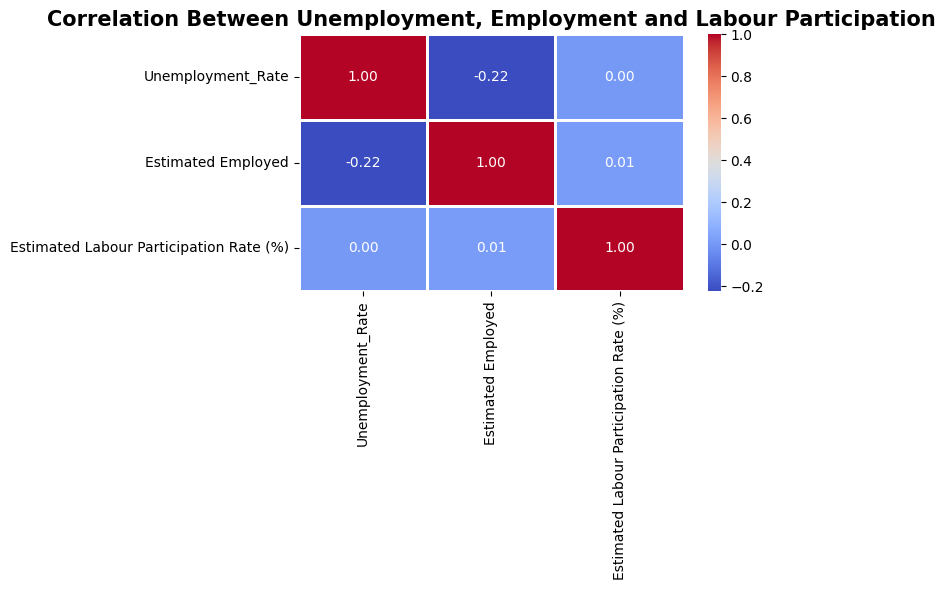

In [28]:
# Graph 6: Correlation Heatmap


correlation = df[
    [
        "Unemployment_Rate",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=1
)

plt.title(
    "Correlation Between Unemployment, Employment and Labour Participation",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

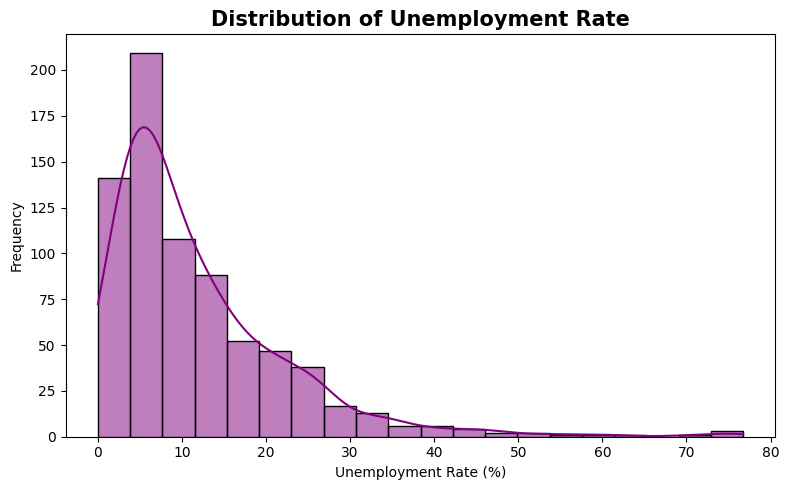

In [29]:
# Graph 7: Distribution


plt.figure(figsize=(8,5))

sns.histplot(
    df["Unemployment_Rate"],
    bins=20,
    kde=True,
    color="purple"
)

plt.title("Distribution of Unemployment Rate", fontsize=15, fontweight="bold")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

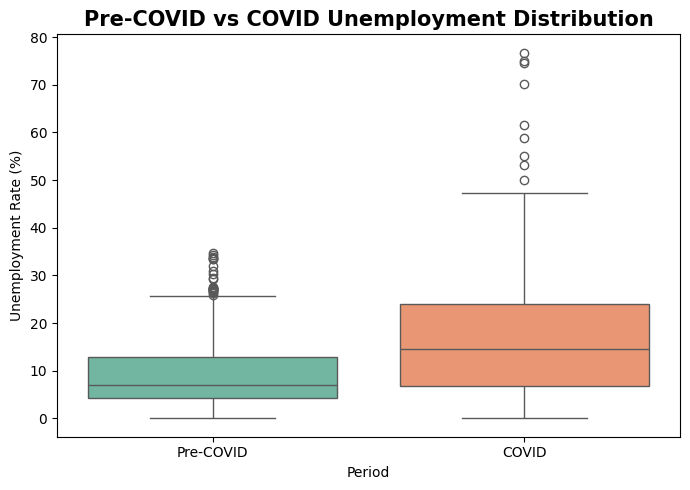

In [30]:

# Graph 8: Boxplot
temp_df = df.copy()

temp_df["Period"] = np.where(
    temp_df["Date"] < "2020-03-25",
    "Pre-COVID",
    "COVID"
)

plt.figure(figsize=(7,5))

sns.boxplot(
    data=temp_df,
    x="Period",
    y="Unemployment_Rate",
    hue="Period",
    legend=False,
    palette="Set2"
)

plt.title("Pre-COVID vs COVID Unemployment Distribution", fontsize=15, fontweight="bold")
plt.xlabel("Period")
plt.ylabel("Unemployment Rate (%)")
plt.tight_layout()
plt.show()

In [38]:
# ADVANCED ANALYSIS
print("ADVANCED ANALYSIS")

# Create Month Name
df["Month_Name"] = df["Date"].dt.month_name()

# Highest & Lowest Unemployment States

highest_state = (
    df.groupby("Region")["Unemployment_Rate"]
      .mean()
      .sort_values(ascending=False)
)

print("\nTop 10 States (Overall Average Unemployment)")
print(highest_state.head(10))

print("\nLowest 10 States")
print(highest_state.tail(10))

# Monthly Trend
monthly = (
    df.groupby("Month_Name")["Unemployment_Rate"]
      .mean()
)

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly = monthly.reindex(month_order)

print("\nMonthly Average")
print(monthly)

# Urban vs Rural Comparison
area_average = (
    df.groupby(["Period","Area"])["Unemployment_Rate"]
      .mean()
      .reset_index()
)

print("\nUrban vs Rural Average")
print(area_average)

# State-wise COVID Comparison
state_compare = (
    df.pivot_table(
        index="Region",
        columns="Period",
        values="Unemployment_Rate",
        aggfunc="mean"
    )
)

state_compare["Increase"] = (
    state_compare["COVID"] -
    state_compare["Pre-COVID"]
)

state_compare = state_compare.sort_values(
    by="Increase",
    ascending=False
)

# COVID Statistics
pre_covid_avg = (
    df[df["Period"]=="Pre-COVID"]["Unemployment_Rate"].mean()
)

covid_avg = (
    df[df["Period"]=="COVID"]["Unemployment_Rate"].mean()
)

increase = (
    (covid_avg-pre_covid_avg)/pre_covid_avg
)*100

national_trend = (
    df.groupby("Date")["Unemployment_Rate"]
      .mean()
      .reset_index()
)

peak = national_trend.loc[
    national_trend["Unemployment_Rate"].idxmax()
]

# POLICY INSIGHTS

print("KEY INSIGHTS")

print(f"""
1. Average unemployment before COVID was
   {pre_covid_avg:.2f}%.

2. During COVID it increased to
   {covid_avg:.2f}%.

3. Overall increase:
   {increase:.2f}%.

4. Peak unemployment occurred on

   {peak['Date'].date()}

   with

   {peak['Unemployment_Rate']:.2f}% unemployment.

5. States experienced different impacts,
   indicating different economic conditions.

6. Urban unemployment remained higher than
   Rural unemployment during COVID.

7. Seasonal unemployment trends are visible.

8. Government policies should focus on
   high-unemployment states.
""")

# SAVE FILES

df.to_csv("unemployment_cleaned.csv", index=False)
print("\n✓ unemployment_cleaned.csv saved.")

state_compare.to_csv("state_covid_comparison.csv")
print("✓ state_covid_comparison.csv saved.")

monthly.to_csv("monthly_unemployment.csv")
print("✓ monthly_unemployment.csv saved.")


# CREATE SUMMARY REPORT

report = []

report.append("UNEMPLOYMENT ANALYSIS REPORT")

report.append(f"\nDataset Size : {df.shape}")

report.append(
    f"Date Range : {df['Date'].min().date()} to {df['Date'].max().date()}"
)

report.append(
    f"States Covered : {df['Region'].nunique()}"
)

report.append(
    f"Areas : {', '.join(df['Area'].unique())}"
)

report.append("\nCOVID IMPACT")


report.append(f"Pre COVID Average : {pre_covid_avg:.2f}%")
report.append(f"COVID Average : {covid_avg:.2f}%")
report.append(f"Increase : {increase:.2f}%")
report.append(f"Peak Date : {peak['Date'].date()}")
report.append(f"Peak Rate : {peak['Unemployment_Rate']:.2f}%")

report.append("\nTop 10 States")


report.append(highest_state.head(10).to_string())

report.append("\nMonthly Trend")


report.append(monthly.to_string())

report.append("\nPolicy Recommendations")


recommendations = [
    "Increase employment opportunities in high unemployment states.",
    "Improve skill development programmes.",
    "Support MSMEs and small businesses.",
    "Promote employment guarantee schemes.",
    "Strengthen rural employment initiatives.",
    "Increase investment in labour-intensive industries.",
    "Expand digital employment opportunities.",
    "Regularly monitor unemployment trends."
]

for i, rec in enumerate(recommendations,1):
    report.append(f"{i}. {rec}")

with open(
    "unemployment_analysis_report.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write("\n".join(report))

print("\n✓ unemployment_analysis_report.txt saved.")

# PROJECT SUMMARY

print("PROJECT COMPLETED SUCCESSFULLY")


print("""
Generated Files

1. unemployment_cleaned.csv
2. state_covid_comparison.csv
3. monthly_unemployment.csv
4. unemployment_analysis_report.txt
5. unemployment_analysis_dashboard.png

Analysis Completed Successfully.
""")

ADVANCED ANALYSIS

Top 10 States (Overall Average Unemployment)
Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Unemployment_Rate, dtype: float64

Lowest 10 States
Region
Maharashtra       7.557500
Andhra Pradesh    7.477143
Madhya Pradesh    7.406429
Sikkim            7.249412
Karnataka         6.676071
Gujarat           6.663929
Uttarakhand       6.582963
Assam             6.428077
Odisha            5.657857
Meghalaya         4.798889
Name: Unemployment_Rate, dtype: float64

Monthly Average
Month_Name
January       9.950755
February      9.964717
March        10.700577
April        23.641569
May          16.646190
June         10.553462
July          9.033889
August        9.637925
September     9.051731
October       9.900